# E05 — TDEM nonconvex slab-depth benchmark


The inversion variable is the scalar slab depth \(z\). Each method is evaluated on the same 181-point depth grid; the resulting one-dimensional objective is interpolated by PCHIP and optimized from the same 23 starting depths. A run is counted as successful when
\[
|z_{\mathrm{final}}-z_\star|<0.01.
\]
The observed trace and candidate traces use different spatial grids to avoid an inverse crime. HV is the expensive stage; progress is printed point by point for each chunk, and all 23 multistarts are printed for every method.

In [9]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [10]:
reset_experiment("E05")

[E05] previous generated results/figures cleared.


In [12]:
E05_WORKERS = 6
print("E05_WORKERS =", E05_WORKERS)
run_py("experiments/E05/code/run_e05.py", "--forward")
run_py("experiments/E05/code/run_e05.py", "--nonhv")
for a, b in [(0,46), (46,92), (92,138), (138,181)]:
    run_py("experiments/E05/code/run_e05.py", "--hv-chunk", a, b, "--workers", E05_WORKERS)
run_py("experiments/E05/code/run_e05.py", "--combine-hv")
run_py("experiments/E05/code/run_e05.py", "--combine-objectives")
run_py("experiments/E05/code/postprocess_e05.py")
run_py("experiments/E05/code/finalize_e05.py")

E05_WORKERS = 6

RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E05/code/run_e05.py --forward

RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E05/code/run_e05.py --nonhv
{
  "runtime_s": 37.494562696665525,
  "Q-vvW2": {
    "epsilon": 0.15,
    "cross_weight": 0.03
  },
  "Softplus-W2sq": {
    "reference": "Qiu 2021, Inverse Problems 37 095004",
    "beta_raw": 109.95695824033257,
    "beta_rule": "beta=2 after one global observed-amplitude nondimensionalization"
  },
  "Marginal-W2sq": {
    "amp_padding": 1.5,
    "amp_grid": 36,
    "lambda_v": 0.03,
    "theta_deg": 45.0,
    "transport": "marginal W_2^2"
  },
  "UOT": {
    "k": 84.70369534833155,
    "reg": 0.001,
    "reg_m": 1.0,
    "iterations": 13500,
    "fixed_point_residual": 9.229950137523701e-12,
    "stabilization": "exact scalar-shape factorization of source scaling variables"
  }
}

RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/

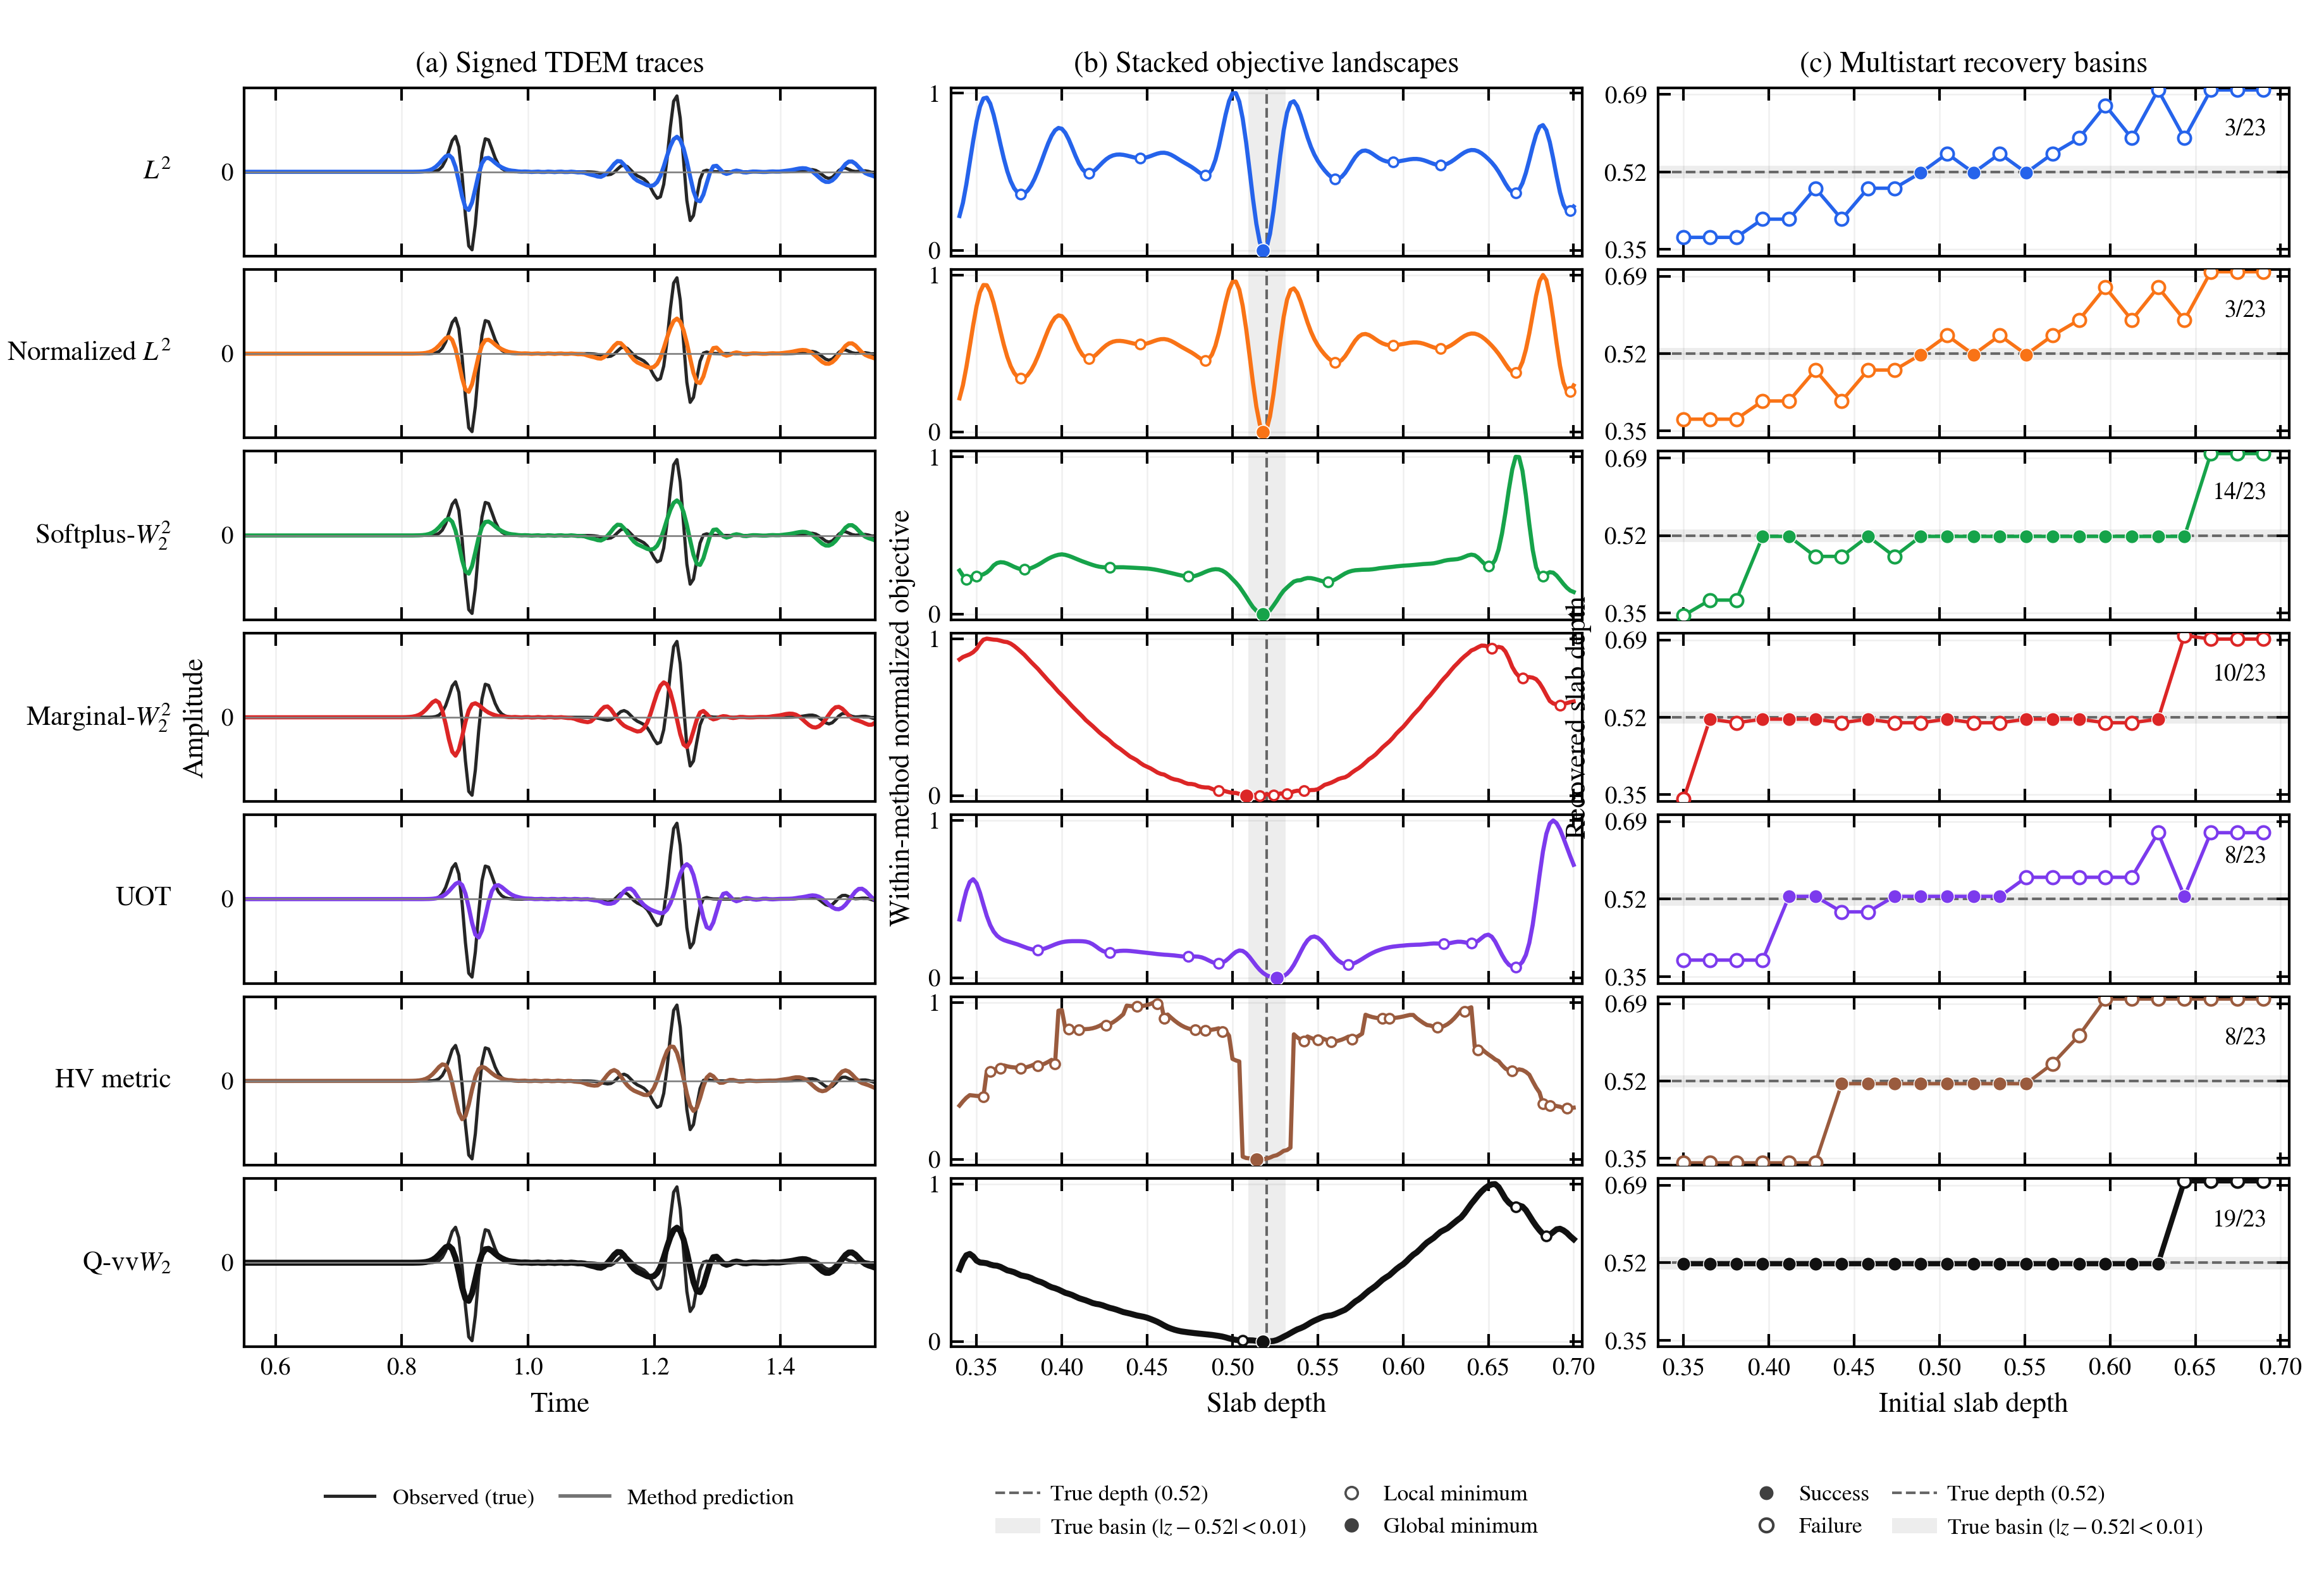

In [13]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

show_png(ROOT / "experiments/E05/figures/Fig09_TDEM_nonconvex_benchmark.png")